In [1]:
import re

# 1. RFC 822 및 RFC 3676 규약에 맞게 올바른 뉴스 포맷 문자열 작성 (생성)
formatted_news_article = """From: alice@example.com
Subject: Hello
Organization: NASA
Lines: 6

This is body text. This is the body content of the email.
I hope this information helps you.

-- 
John Doe
Senior Software Engineer
Company Inc."""


# 2. RFC 규약에 따라 Header, Body, Footer를 구분(파싱)하는 함수
def parse_rfc822_news(text):
    # A. Header와 나머지(Body + Footer) 분리: 첫 번째 빈 줄(\n\s*\n) 기준
    header_split = re.split(r'\n\s*\n', text, maxsplit=1)
    
    header = header_split[0].strip() if len(header_split) > 0 else ""
    remainder = header_split[1] if len(header_split) > 1 else ""

    # B. Body와 Footer 분리: RFC 표준 서명 구분선(\n-- \n) 기준
    footer_split = re.split(r'\n-- \n', remainder, maxsplit=1)
    
    body = footer_split[0].strip() if len(footer_split) > 0 else ""
    footer = footer_split[1].strip() if len(footer_split) > 1 else ""

    return {
        "header": header,
        "body": body,
        "footer": footer
    }


# 3. 파싱 함수 실행 및 결과 확인
parsed_result = parse_rfc822_news(formatted_news_article)

print("=== 1. HEADER (메타데이터) ===")
print(parsed_result["header"])

print("\n=== 2. BODY (순수 본문) ===")
print(parsed_result["body"])

print("\n=== 3. FOOTER (서명) ===")
print(parsed_result["footer"] if parsed_result["footer"] else "(Footer 없음)")

=== 1. HEADER (메타데이터) ===
From: alice@example.com
Subject: Hello
Organization: NASA
Lines: 6

=== 2. BODY (순수 본문) ===
This is body text. This is the body content of the email.
I hope this information helps you.

=== 3. FOOTER (서명) ===
John Doe
Senior Software Engineer
Company Inc.


In [2]:
from sklearn.datasets import fetch_20newsgroups

news = fetch_20newsgroups(subset='all')
print(news.target_names)

['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware', 'comp.windows.x', 'misc.forsale', 'rec.autos', 'rec.motorcycles', 'rec.sport.baseball', 'rec.sport.hockey', 'sci.crypt', 'sci.electronics', 'sci.med', 'sci.space', 'soc.religion.christian', 'talk.politics.guns', 'talk.politics.mideast', 'talk.politics.misc', 'talk.religion.misc']


In [3]:
# scikit-learn에서 20개 뉴스그룹 텍스트 데이터셋을 가져오는 함수 불러오기
from sklearn.datasets import fetch_20newsgroups

# 데이터 처리를 위해 pandas 라이브러리를 불러오고 pd라는 별칭으로 사용
import pandas as pd

# fetch_20newsgroups() 함수를 사용해 전체 데이터 로드
# subset='all': 학습용(train)과 평가용(test)을 합친 전체 데이터셋(~18,846개 문서)을 가져옴
news = fetch_20newsgroups(subset='all')

# 텍스트 본문(news.data)과 카테고리 라벨(news.target)을 매핑하여 Pandas DataFrame 객체 생성
# 'text': 뉴스 기사의 본문 내용이 들어가는 컬럼
# 'target': 각 기사가 20개 토픽 중 몇 번째 토픽에 속하는지 나타내는 숫자 라벨(0~19) 컬럼
df_loaded = pd.DataFrame({
    'text': news.data,
    'target': news.target
})

# 숫자 라벨(0~19)을 실제 텍스트 형태의 카테고리 이름으로 변환한 'target_name' 컬럼 추가
# 예: 0 -> 'alt.atheism', 1 -> 'comp.graphics', ...
df_loaded['target_name'] = df_loaded['target'].apply(lambda x: news.target_names[x])

# 생성된 DataFrame의 상위 5개 행 미리보기
print(df_loaded.head())

                                                text  target  \
0  From: Mamatha Devineni Ratnam <mr47+@andrew.cm...      10   
1  From: mblawson@midway.ecn.uoknor.edu (Matthew ...       3   
2  From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...      17   
3  From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...       3   
4  From: Alexander Samuel McDiarmid <am2o+@andrew...       4   

                target_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  


In [4]:
df_loaded.head()

,text,target,target_name
0,From: Mamatha Devineni Ratnam <mr47+@andrew.cm...,10,rec.sport.hockey
1,From: mblawson@midway.ecn.uoknor.edu (Matthew ...,3,comp.sys.ibm.pc.hardware
2,From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...,17,talk.politics.mideast
3,From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...,3,comp.sys.ibm.pc.hardware
4,From: Alexander Samuel McDiarmid <am2o+@andrew...,4,comp.sys.mac.hardware


In [5]:
# 숫자 라벨(0~19)을 실제 텍스트 형태의 카테고리 이름으로 변환한 'target_name' 컬럼 추가
# 예: 0 -> 'alt.atheism', 1 -> 'comp.graphics', ...
df_loaded['target_name'] = df_loaded['target'].apply(lambda x: news.target_names[x])

# 생성된 DataFrame의 상위 5개 행 미리보기
print(df_loaded.head())

                                                text  target  \
0  From: Mamatha Devineni Ratnam <mr47+@andrew.cm...      10   
1  From: mblawson@midway.ecn.uoknor.edu (Matthew ...       3   
2  From: hilmi-er@dsv.su.se (Hilmi Eren)\nSubject...      17   
3  From: guyd@austin.ibm.com (Guy Dawson)\nSubjec...       3   
4  From: Alexander Samuel McDiarmid <am2o+@andrew...       4   

                target_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  
3  comp.sys.ibm.pc.hardware  
4     comp.sys.mac.hardware  


In [6]:
import pandas as pd
from sklearn.datasets import fetch_20newsgroups

# 1. remove 옵션을 지정하여 노이즈(headers, footers, quotes)가 제거된 뉴스 데이터 로드
# subset='all': 학습(train) 및 평가(test) 데이터를 모두 합친 전체 데이터셋 로드
news = fetch_20newsgroups(
    subset='all', 
    remove=('headers', 'footers', 'quotes')
)

# 2. 본문(text)과 숫자 라벨(target)을 사용해 기본 DataFrame 생성
df = pd.DataFrame({
    'text': news.data,
    'target': news.target
})

# 3. 숫자 라벨(0~19)을 실제 카테고리 텍스트 이름으로 매핑하여 컬럼 추가
df['target_name'] = df['target'].apply(lambda x: news.target_names[x])

# 4. 노이즈 제거 후 빈 문자열("")만 남거나 공백만 있는 문서 제거 (데이터 정제)
# (headers/footers/quotes를 지우면서 본문 내용이 아예 없는 문서가 생길 수 있음)
df['text'] = df['text'].str.strip()
df = df[df['text'] != ''].reset_index(drop=True)

# 5. 결과 확인
print("# 전체 데이터 개수 (빈 본문 제거 후):", len(df))
print("\n# 상위 3개 행 미리보기:")
print(df.head(3))

# 전체 데이터 개수 (빈 본문 제거 후): 18331

# 상위 3개 행 미리보기:
                                                text  target  \
0  I am sure some bashers of Pens fans are pretty...      10   
1  My brother is in the market for a high-perform...       3   
2  Finally you said what you dream about. Mediter...      17   

                target_name  
0          rec.sport.hockey  
1  comp.sys.ibm.pc.hardware  
2     talk.politics.mideast  


In [7]:
# scikit-learn 데이터셋 모듈에서 20개 뉴스그룹 데이터를 불러오는 함수 가져오기
from sklearn.datasets import fetch_20newsgroups
# 텍스트 데이터를 단어 빈도수 기반의 수치형 행렬로 변환하는 CountVectorizer 불러오기
from sklearn.feature_extraction.text import CountVectorizer
# 다항 나이브 베이즈(Multinomial Naive Bayes) 분류 모델 불러오기
from sklearn.naive_bayes import MultinomialNB
# 모델의 분류 성능 평가를 위한 정확도(accuracy_score) 함수 가져오기
from sklearn.metrics import accuracy_score

# 1. 사용할 4개 뉴스그룹 카테고리 지정
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']

# 2. 학습(Train) 및 검증(Test) 데이터셋 로드
# remove=('headers', 'footers', 'quotes'): 힌트가 되는 정형화된 정보를 제거하여 순수 본문으로만 분류하도록 설정
newsgroups_train = fetch_20newsgroups(subset='train',
                                      remove=('headers', 'footers', 'quotes'),
                                      categories=categories)

newsgroups_test = fetch_20newsgroups(subset='test', 
                                     remove=('headers', 'footers', 'quotes'),
                                     categories=categories)

# 3. 데이터셋 기본 정보 출력
print('#Train set size:', len(newsgroups_train.data))
print('#Test set size:', len(newsgroups_test.data))
print('#Selected categories:', newsgroups_train.target_names)
print('#Train labels:', set(newsgroups_train.target))

# 4. 텍스트 카운트 벡터화(CountVectorizer) 객체 생성
# max_features=2000: 상위 2,000개 단어만 피처로 추출
# min_df=5: 최소 5개 문서 이상 등장한 단어만 포함
# max_df=0.5: 전체 문서의 50%를 초과하는 흔한 단어는 제외
cv = CountVectorizer(max_features=2000, min_df=5, max_df=0.5)

# 5. 텍스트 데이터를 수치형 벡터 행렬로 변환
# 학습 데이터셋(X_train)은 fit_transform()을 사용해 단어장을 학습함과 동시에 변환
X_train_cv = cv.fit_transform(newsgroups_train.data)
print(f'X_train_cv:{X_train_cv[:2]}')
y_train = newsgroups_train.target

# 평가 데이터셋(X_test)은 학습 데이터에서 만들어진 단어장을 기준으로 transform()만 수행 (Data Leakage 방지)
X_test_cv = cv.transform(newsgroups_test.data)
y_test = newsgroups_test.target

# 6. 나이브 베이즈 모델 생성 및 학습
nb_model = MultinomialNB()
nb_model.fit(X_train_cv, y_train)

# 7. 검증 데이터셋에 대한 예측 수행 및 성능 평가
pred = nb_model.predict(X_test_cv)
print('#Test Set Accuracy:', round(accuracy_score(y_test, pred), 4))

#Train set size: 2034
#Test set size: 1353
#Selected categories: ['alt.atheism', 'comp.graphics', 'sci.space', 'talk.religion.misc']
#Train labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3)}
X_train_cv:<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 69 stored elements and shape (2, 2000)>
  Coords	Values
  (0, 826)	1
  (0, 1882)	1
  (0, 863)	2
  (0, 1994)	3
  (0, 1243)	1
  (0, 1550)	2
  (0, 1132)	1
  (0, 1959)	1
  (0, 119)	1
  (0, 1996)	1
  (0, 1073)	1
  (0, 686)	6
  (0, 1941)	1
  (0, 105)	1
  (0, 1784)	1
  (0, 182)	2
  (0, 763)	1
  (0, 491)	1
  (0, 1358)	1
  (0, 302)	1
  (0, 1774)	1
  (0, 1359)	1
  (0, 548)	2
  (0, 158)	2
  (0, 960)	1
  :	:
  (1, 1959)	1
  (1, 119)	1
  (1, 1009)	1
  (1, 246)	1
  (1, 808)	1
  (1, 1574)	1
  (1, 627)	1
  (1, 431)	1
  (1, 965)	2
  (1, 1920)	1
  (1, 1623)	1
  (1, 151)	1
  (1, 1947)	1
  (1, 1796)	1
  (1, 1739)	1
  (1, 1948)	1
  (1, 702)	1
  (1, 831)	1
  (1, 353)	1
  (1, 833)	1
  (1, 930)	1
  (1, 25)	1
  (1, 251)	1
  (1, 1715)	1
  (1, 6

In [8]:
# 20newsgroups 학습 데이터셋에서 텍스트 본문 리스트 추출 (독립변수 X)
X_train = newsgroups_train.data   #학습 데이터셋 문서

# 20newsgroups 학습 데이터셋에서 각 문서의 카테고리 라벨(0~19) 추출 (종속변수 y)
y_train = newsgroups_train.target #학습 데이터셋 라벨

# 20newsgroups 평가/검증 데이터셋에서 텍스트 본문 리스트 추출 (독립변수 X)
X_test = newsgroups_test.data     #검증 데이터셋 문서

# 20newsgroups 평가/검증 데이터셋에서 각 문서의 카테고리 라벨(0~19) 추출 (종속변수 y)
y_test = newsgroups_test.target   #검증 데이터셋 라벨

# scikit-learn의 텍스트 피처 추출 모듈에서 텍스트를 단어 빈도수 행렬로 변환하는 CountVectorizer 불러오기
from sklearn.feature_extraction.text import CountVectorizer

# CountVectorizer 객체 생성 및 핵심 피처 선택 기준 설정
# max_features=2000: 빈도수 상위 2,000개 단어만 피처(열)로 사용
# min_df=5: 최소 5개 이상의 문서에 출현한 단어만 포함 (희귀 단어/오타 제거)
# max_df=0.5: 전체 문서의 50%를 초과하여 등장하는 단어는 제외 (흔한 불용어 제거)
cv = CountVectorizer(max_features=2000, min_df=5, max_df=0.5)


# [매우 중요] 학습 데이터셋(X_train)을 바탕으로 단어장을 학습(fit)함과 동시에 희소 행렬(Sparse Matrix)로 변환(transform)
# fit: X_train 텍스트 분석 후 규칙(min_df, max_df 등)에 맞는 단어장 사전(vocabulary) 형성
# transform: 해당 단어장 기준으로 각 문서의 단어 빈도수를 카운트하여 행렬로 변환
X_train_cv = cv.fit_transform(X_train) # train set을 변환

# 변환된 학습 행렬의 차원 출력 (행의 수: 문서 개수, 열의 수: 추출된 단어 피처 수 = 최대 2,000개)
print('Train set dimension:', X_train_cv.shape) 

# [매우 중요] 학습 데이터에서 이미 만들어진 단어장(cv)을 기준으로 평가 데이터셋(X_test)을 변환만(transform) 수행
# ★주의★: X_test에는 절대 fit_transform을 사용하면 안 됨 (학습셋과 검증셋의 단어장 기준/열 매핑이 달라지는 Data Leakage 발생 방지)
X_test_cv = cv.transform(X_test) # test set을 변환

# 변환된 평가 행렬의 차원 출력 (행의 수: 검증 문서 개수, 열의 수: X_train과 동일한 단어 피처 수)
print('Test set dimension:', X_test_cv.shape)

# cv.fit_transform을 통해 학습되어 최종 선택된 단어들과 각 단어의 인덱스(열 번호) 매핑 딕셔너리 출력
# 형태: {'단어': 인덱스번호, ...} (예: {'space': 0, 'nasa': 1, ...})
print(cv.vocabulary_)
print(len(cv.vocabulary_))


Train set dimension: (2034, 2000)
Test set dimension: (1353, 2000)
{'hi': np.int64(826), 've': np.int64(1882), 'if': np.int64(863), 'you': np.int64(1994), 'only': np.int64(1243), 'save': np.int64(1550), 'model': np.int64(1132), 'with': np.int64(1959), 'all': np.int64(119), 'your': np.int64(1996), 'mapping': np.int64(1073), 'file': np.int64(686), 'when': np.int64(1941), 'after': np.int64(105), 'they': np.int64(1784), 'are': np.int64(182), 'given': np.int64(763), 'default': np.int64(491), 'position': np.int64(1358), 'but': np.int64(302), 'their': np.int64(1774), 'positions': np.int64(1359), 'does': np.int64(548), 'anyone': np.int64(158), 'know': np.int64(960), 'why': np.int64(1951), 'this': np.int64(1791), 'information': np.int64(891), 'not': np.int64(1205), 'nothing': np.int64(1209), 'said': np.int64(1541), 'manual': np.int64(1070), 'about': np.int64(70), 'rules': np.int64(1534), 'like': np.int64(1009), 'be': np.int64(246), 'able': np.int64(68), 'read': np.int64(1454), 'rule': np.int64(

In [9]:
# zip() 함수를 사용해 단어 리스트와 해당 단어의 빈도수 배열을 1:1로 묶어 순회
# 1. cv.get_feature_names_out()[:100]: CountVectorizer가 구축한 전체 단어장에서 인덱스 0~99까지 상위 100개 단어 추출
# 2. X_train_cv[0].toarray()[0, :100]:
#    - X_train_cv[0]: 첫 번째 뉴스 문서(Row 0)의 희소 행렬(Sparse Matrix) 데이터
#    - .toarray(): 메모리 절약을 위한 희소 행렬을 일반 2차원 넘파이 배열(Dense Array)로 변환
#    - [0, :100]: 변환된 2차원 배열의 첫 번째 행에서 인덱스 0~99까지 상위 100개 단어의 빈도수(Count) 추출
for word, count in zip(cv.get_feature_names_out()[:100], X_train_cv[0].toarray()[0, :100]):
    # '단어 : 빈도수' 형태로 출력하며, end=', '를 통해 줄바꿈 대신 쉼표와 공백으로 이어붙여 출력
    print(word, ':', count, end=', ')

00 : 0, 000 : 0, 01 : 0, 04 : 0, 05 : 0, 10 : 0, 100 : 0, 1000 : 0, 11 : 0, 12 : 0, 128 : 0, 129 : 0, 13 : 0, 130 : 0, 14 : 0, 15 : 0, 16 : 0, 17 : 0, 18 : 0, 19 : 0, 1988 : 0, 1989 : 0, 1990 : 0, 1991 : 0, 1992 : 0, 1993 : 0, 20 : 0, 200 : 0, 202 : 0, 21 : 0, 22 : 0, 23 : 0, 24 : 0, 25 : 0, 256 : 0, 26 : 0, 27 : 0, 28 : 0, 2d : 0, 30 : 0, 300 : 0, 31 : 0, 32 : 0, 33 : 0, 34 : 0, 35 : 0, 39 : 0, 3d : 0, 40 : 0, 400 : 0, 42 : 0, 45 : 0, 50 : 0, 500 : 0, 60 : 0, 600 : 0, 65 : 0, 70 : 0, 75 : 0, 80 : 0, 800 : 0, 90 : 0, 91 : 0, 92 : 0, 93 : 0, 95 : 0, _the : 0, ability : 0, able : 1, abortion : 0, about : 1, above : 0, absolute : 0, absolutely : 0, ac : 0, accept : 0, acceptable : 0, accepted : 0, access : 0, according : 0, account : 0, accurate : 0, across : 0, act : 0, action : 0, actions : 0, active : 0, activities : 0, activity : 0, acts : 0, actual : 0, actually : 0, ad : 0, add : 0, added : 0, addition : 0, additional : 0, address : 0, addresses : 0, admit : 0, 

In [10]:
import math
from collections import Counter

# =====================================================================
# 1. 학습 데이터 세트 준비 (이미지 속 표 데이터를 리스트 형태로 작성)
# =====================================================================
# 각 튜플은 ([이메일 단어 리스트], 분류 라벨) 형식입니다. (1: 스팸, 0: 정상)
train_data = [
    (["무료", "대출", "신청"], 1),                   # 스팸 1
    (["내일", "회의", "일정"], 0),                   # 정상 1
    (["당첨", "무료", "상품", "클릭"], 1),             # 스팸 2
    (["오늘", "저녁", "약속", "시간", "변경"], 0),      # 정상 2
    (["긴급", "대출", "한도", "조회"], 1),             # 스팸 3
    (["주문하신", "상품이", "발송되었습니다"], 0)       # 정상 3
]


# =====================================================================
# 2. 나이브 베이즈 모델 학습 함수
# =====================================================================
def train_naive_bayes(data):
    """
    학습 데이터를 바탕으로 사전 확률과 각 클래스별 단어 빈도수를 계산합니다.
    """
    # [단계 1] 전체 문서 수 및 스팸/정상 메일 수 세기
    num_spam = sum(1 for _, label in data if label == 1) # 스팸 메일 개수 (3개)
    num_ham = sum(1 for _, label in data if label == 0)  # 정상 메일 개수 (3개)
    total_docs = len(data)                              # 전체 메일 개수 (6개)
    
    # [단계 2] 사전 확률 P(스팸), P(정상) 구하기
    # P(스팸) = 전체 메일 중 스팸 비율 = 3/6 = 0.5
    p_spam = num_spam / total_docs
    # P(정상) = 전체 메일 중 정상 비율 = 3/6 = 0.5
    p_ham = num_ham / total_docs
    
    # [단계 3] 각 클래스별 단어 모으기 및 전체 어휘 사전(Vocabulary) 구성
    spam_words = []   # 스팸 메일에 등장한 모든 단어들의 목록 (중복 포함)
    ham_words = []    # 정상 메일에 등장한 모든 단어들의 목록 (중복 포함)
    vocabulary = set() # 중복을 제거한 전체 고유 단어 집합
    
    for words, label in data:
        vocabulary.update(words)  # 고유 단어 집합에 단어 추가
        if label == 1:
            spam_words.extend(words) # 스팸 단어 목록에 추가
        else:
            ham_words.extend(words)  # 정상 단어 목록에 추가
            
    # [단계 4] 단어별 빈도수 계산 (예: '무료': 2회, '대출': 2회 ...)
    spam_counts = Counter(spam_words)
    print(f'spam_counts:{spam_counts}')
    ham_counts = Counter(ham_words)
    print(f'ham_counts:{ham_counts}')

    # 계산된 학습 정보들을 반환
    return p_spam, p_ham, spam_counts, ham_counts, len(spam_words), len(ham_words), vocabulary


# =====================================================================
# 3. 테스트 이메일 분류 및 확률 계산 함수 (라플라스 스무딩 적용)
# =====================================================================
def classify_email(email_words, alpha=1.0):
    """
    새로운 이메일이 들어왔을 때, 라플라스 스무딩을 적용하여 
    P(스팸|이메일), P(정상|이메일), P(이메일)을 구합니다.
    """
    # 학습된 결과물 불러오기
    p_spam, p_ham, spam_counts, ham_counts, total_spam_words, total_ham_words, vocab = train_naive_bayes(train_data)
    
    # [스무딩 핵심 1] 어휘 사전 크기 |V| 확정하기
    # 학습 데이터 단어 집합 + 테스트 메일에 처음 등장한 단어까지 포함한 전체 고유 단어 수
    full_vocab = vocab.union(set(email_words))
    v_size = len(full_vocab) # 어휘 사전의 크기 |V|
    print(f'어휘 사전 크기: {v_size}')
    
    # [단계 5] 우도(Likelihood) 계산 초기화
    # P(이메일|스팸) = P(단어1|스팸) * P(단어2|스팸) * ...
    likelihood_spam = 1.0  # 스팸 우도 초기값 (곱셈을 위해 1로 시작)
    likelihood_ham = 1.0   # 정상 우도 초기값
    
    # [단계 6] 이메일에 포함된 각 단어별 우도 계산 (라플라스 스무딩 공식 적용)
    # 공식: P(단어|클래스) = (단어 빈도수 + alpha) / (해당 클래스 총 단어 수 + alpha * |V|)
    for word in email_words:
        # --- 스팸 메일일 경우 단어 확률 P(word|스팸) ---
        word_spam_count = spam_counts[word] # 스팸에서 해당 단어가 나온 횟수 (없으면 0)
        p_w_given_spam = (word_spam_count + alpha) / (total_spam_words + alpha * v_size)
        likelihood_spam *= p_w_given_spam   # 우도값 누적 곱셈
        
        # --- 정상 메일일 경우 단어 확률 P(word|정상) ---
        word_ham_count = ham_counts[word]   # 정상에서 해당 단어가 나온 횟수 (없으면 0)
        p_w_given_ham = (word_ham_count + alpha) / (total_ham_words + alpha * v_size)
        likelihood_ham *= p_w_given_ham     # 우도값 누적 곱셈
        
    # [단계 7] 분자 값(Unnormalized Posterior) 계산
    # 베이즈 정리 분자 = P(이메일|클래스) * P(클래스)
    numerator_spam = likelihood_spam * p_spam # 스팸 분자 값
    numerator_ham = likelihood_ham * p_ham   # 정상 분자 값
    
    # [단계 8] 증거 확률 P(이메일) 계산 (분모 값)
    # P(이메일) = P(이메일|스팸)*P(스팸) + P(이메일|정상)*P(정상)
    p_email = numerator_spam + numerator_ham
    
    # [단계 9] 최종 사후 확률 P(스팸|이메일), P(정상|이메일) 계산 (정규화)
    # 공식: P(클래스|이메일) = (우도 * 사전확률) / P(이메일)
    posterior_spam = numerator_spam / p_email # 최종 스팸일 확률
    posterior_ham = numerator_ham / p_email   # 최종 정상일 확률
    
    return posterior_spam, posterior_ham, p_email, likelihood_spam, likelihood_ham


# =====================================================================
# 4. 실행 및 결과 출력
# =====================================================================
if __name__ == "__main__":
    # 판별하고자 하는 새로운 테스트 이메일 단어
    test_email = ["오늘", "긴급", "대출"]
    
    # 라플라스 스무딩(alpha=1.0) 적용하여 함수 실행
    p_spam_given_email, p_ham_given_email, p_email, l_spam, l_ham = classify_email(test_email, alpha=1.0)
    
    print("==================================================")
    print(f" 📧 테스트 이메일: '{' '.join(test_email)}'")
    print("==================================================")
    print(f"1. P(스팸) [사전 확률]: 0.5000 (전체 6개 중 3개)")
    print(f"2. P(이메일|스팸) [스팸 우도]: {l_spam:.6f}")
    print(f"3. P(이메일|정상) [정상 우도]: {l_ham:.6f}")
    print(f"4. P(이메일) [전체 증거 확률]: {p_email:.6f}")
    print("--------------------------------------------------")
    print(f"5. 최종 결과:")
    print(f"   - P(스팸 | 이메일) : {p_spam_given_email * 100:.2f}%")
    print(f"   - P(정상 | 이메일) : {p_ham_given_email * 100:.2f}%")
    print("--------------------------------------------------")
    
    # 최종 클래스 판정
    if p_spam_given_email > p_ham_given_email:
        print(" 🚨 최종 분류 결과: [스팸 메일]로 판정되었습니다.")
    else:
        print(" ✅ 최종 분류 결과: [정상 메일]로 판정되었습니다.")

spam_counts:Counter({'무료': 2, '대출': 2, '신청': 1, '당첨': 1, '상품': 1, '클릭': 1, '긴급': 1, '한도': 1, '조회': 1})
ham_counts:Counter({'내일': 1, '회의': 1, '일정': 1, '오늘': 1, '저녁': 1, '약속': 1, '시간': 1, '변경': 1, '주문하신': 1, '상품이': 1, '발송되었습니다': 1})
어휘 사전 크기: 20
 📧 테스트 이메일: '오늘 긴급 대출'
1. P(스팸) [사전 확률]: 0.5000 (전체 6개 중 3개)
2. P(이메일|스팸) [스팸 우도]: 0.000201
3. P(이메일|정상) [정상 우도]: 0.000067
4. P(이메일) [전체 증거 확률]: 0.000134
--------------------------------------------------
5. 최종 결과:
   - P(스팸 | 이메일) : 75.00%
   - P(정상 | 이메일) : 25.00%
--------------------------------------------------
 🚨 최종 분류 결과: [스팸 메일]로 판정되었습니다.


In [11]:
vocabulary = set()
print(vocabulary)

vocabulary.update(["무료", "대출", "신청"])
print(vocabulary)

vocabulary.update(["무료", "광고", "신청"])

set()
{'대출', '신청', '무료'}


In [12]:
# scikit-learn의 naive_bayes 모듈에서 다항 나이브 베이즈(Multinomial Naive Bayes) 분류기 클래스를 불러옵니다.
# MultinomialNB는 텍스트 데이터의 단어 카운트(빈도수)나 TF-IDF 벡터 형태를 처리하기에 가장 적합한 나이브 베이즈 모델입니다.
from sklearn.naive_bayes import MultinomialNB #sklearn이 제공하는 MultinomialNB 를 사용

# MultinomialNB 객체(분류기) 생성 및 선언
# 기본적으로 alpha=1.0이 설정되어 있어 Zero Frequency(데이터 미등장 단어로 인한 확률 0 방지)를 막는 라플라스 스무딩(Laplace Smoothing)이 자동 적용됩니다.
NB_clf = MultinomialNB() # 분류기 선언

# fit() 메서드를 사용하여 학습 데이터셋(X_train_cv, y_train)으로 나이브 베이즈 분류기 모델 학습
# 각 카테고리(클래스)별 사전 확률(Prior)과 각 단어의 가능도(Likelihood)를 학습 데이터의 빈도수 기반으로 계산합니다.
NB_clf.fit(X_train_cv, y_train) #train set을 이용하여 분류기(classifier)를 학습

# score() 메서드는 입력받은 텍스트 벡터 데이터에 대해 예측을 수행한 후, 실제 라벨 값과 비교하여 정확도(Accuracy, 0.0 ~ 1.0)를 산출합니다.
# Train set score: 모델이 학습에 사용된 데이터(X_train_cv)를 얼마나 잘 분류하는지 확인 (과대적합/Overfitting 여부 판단에 활용)
print('Train set score: {:.3f}'.format(NB_clf.score(X_train_cv, y_train))) #train set에 대한 예측정확도를 확인

# Test set score: 모델이 한 번도 보지 못한 검증 데이터(X_test_cv)를 얼마나 잘 분류하는지 확인 (실제 일반화 성능 평가)
print('Test set score: {:.3f}'.format(NB_clf.score(X_test_cv, y_test))) #test set에 대한 예측정확도를 확인

Train set score: 0.828
Test set score: 0.735


In [ ]:
# scikit-learn의 feature_extraction.text 모듈에서 TF-IDF 수치화 변환기 클래스를 불러옵니다.
from sklearn.feature_extraction.text import TfidfVectorizer
# 배열 처리 및 정렬 연산을 위한 NumPy 라이브러리 불러오기
import numpy as np

# CountVectorizer와 동일한 피처 정제 조건으로 TfidfVectorizer 객체 생성
# - max_features=2000: TF-IDF 점수/단어 빈도 기준 상위 2,000개 단어만 선택
# - min_df=5: 최소 5개 문서 이상 출현한 단어만 포함 (희귀 단어/오타 제거)
	# - max_df=0.5: 전체 문서의 50%를 초과하여 너무 자주 등장하는 일반 단어 제거
tfidf = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.5)

# [학습 단계] 학습 데이터셋(X_train)을 바탕으로 단어장 사전 구축(fit) 및 TF-IDF 희소 행렬 변환(transform) 수행
X_train_tfidf = tfidf.fit_transform(X_train) # train set을 변환

# [검증 단계] 학습 데이터에서 만들어진 기준 단어장(tfidf)에 맞춰 평가 데이터셋(X_test)을 변환만 수행 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test) # test set을 변환

# TF-IDF 변환된 학습 행렬(X_train_tfidf)과 정답 라벨(y_train)을 사용하여 나이브 베이즈 분류기(NB_clf)를 재학습
NB_clf.fit(X_train_tfidf, y_train) #tfidf train set을 이용하여 분류기(classifier)를 새로 학습

# TF-IDF 기반으로 학습된 모델의 학습 데이터셋 예측 정확도(Accuracy) 산출
print('Train set score: {:.3f}'.format(NB_clf.score(X_train_tfidf, y_train))) #train set에 대한 예측정확도를 확인

# TF-IDF 기반으로 학습된 모델의 검증 데이터셋 예측 정확도(Accuracy) 산출 (일반화 성능 확인)
print('Test set score: {:.3f}'.format(NB_clf.score(X_test_tfidf, y_test))) #test set에 대한 예측정확도를 확인


# 나이브 베이즈 모델(classifier), 벡터화 객체(vectorizer), 카테고리 이름 리스트(categories)를 전달받아 
# 각 카테고리를 대표하는 상위 10개 단어를 추출하여 출력하는 함수 정의
def top10_features(classifier, vectorizer, categories):
    # vectorizer에서 추출한 전체 단어장 목록(NumPy 배열 형태)을 반환받음
    # get_feature_names_out(): 단어장 인덱스 순서대로 단어 문자열들이 들어있는 1D 배열 반환
    feature_names = np.asarray(vectorizer.get_feature_names_out())
    
    # 전달받은 카테고리 리스트를 순회하며 인덱스(i)와 카테고리명(category)을 함께 추출
    for i, category in enumerate(categories):
        # classifier.feature_log_prob_[i]: i번째 카테고리에 대한 각 단어 피처들의 조건부 로그 가능도(Log Likelihood) 배열
        # -classifier.feature_log_prob_[i]: 값들을 음수(-)로 만들어 가장 가중치/확률이 큰 높은 값이 가장 작은 음수가 되도록 변환
        # np.argsort(): 오름차순 정렬 시 원래 값들의 '인덱스 번호'를 반환하는 함수
        # [:10]: 가장 높은 가능도를 가졌던 상위 10개 단어의 인덱스 슬라이싱
        top10 = np.argsort(-classifier.feature_log_prob_[i])[:10]
        
        # feature_names[top10]: 팬시 인덱싱(Fancy Indexing)을 사용해 10개 인덱스에 해당하는 실제 단어 문자열들을 추출
        # ", ".join(...): 추출된 10개 단어들을 쉼표와 공백으로 연결하여 출력
        print("%s: %s" % (category, ", ".join(feature_names[top10])))

# 정의한 함수 실행: 학습된 나이브 베이즈 모델(NB_clf), TF-IDF 변환기(tfidf), 카테고리 이름 리스트 전달
top10_features(NB_clf, tfidf, newsgroups_train.target_names)

Train set score: 0.862
Test set score: 0.741
alt.atheism: you, not, are, be, this, have, as, what, they, if
comp.graphics: you, on, graphics, this, have, any, can, or, with, thanks
sci.space: space, on, you, be, was, this, as, they, have, are
talk.religion.misc: you, not, he, are, as, this, be, god, was, they


<>:55: SyntaxWarning: invalid escape sequence '\l'
<>:55: SyntaxWarning: invalid escape sequence '\l'
C:\Users\playdata2\AppData\Local\Temp\ipykernel_19612\687574625.py:55: SyntaxWarning: invalid escape sequence '\l'
  axes[i].set_xlabel("Log Probability ($\log P(x_i | C)$)", fontsize=10)


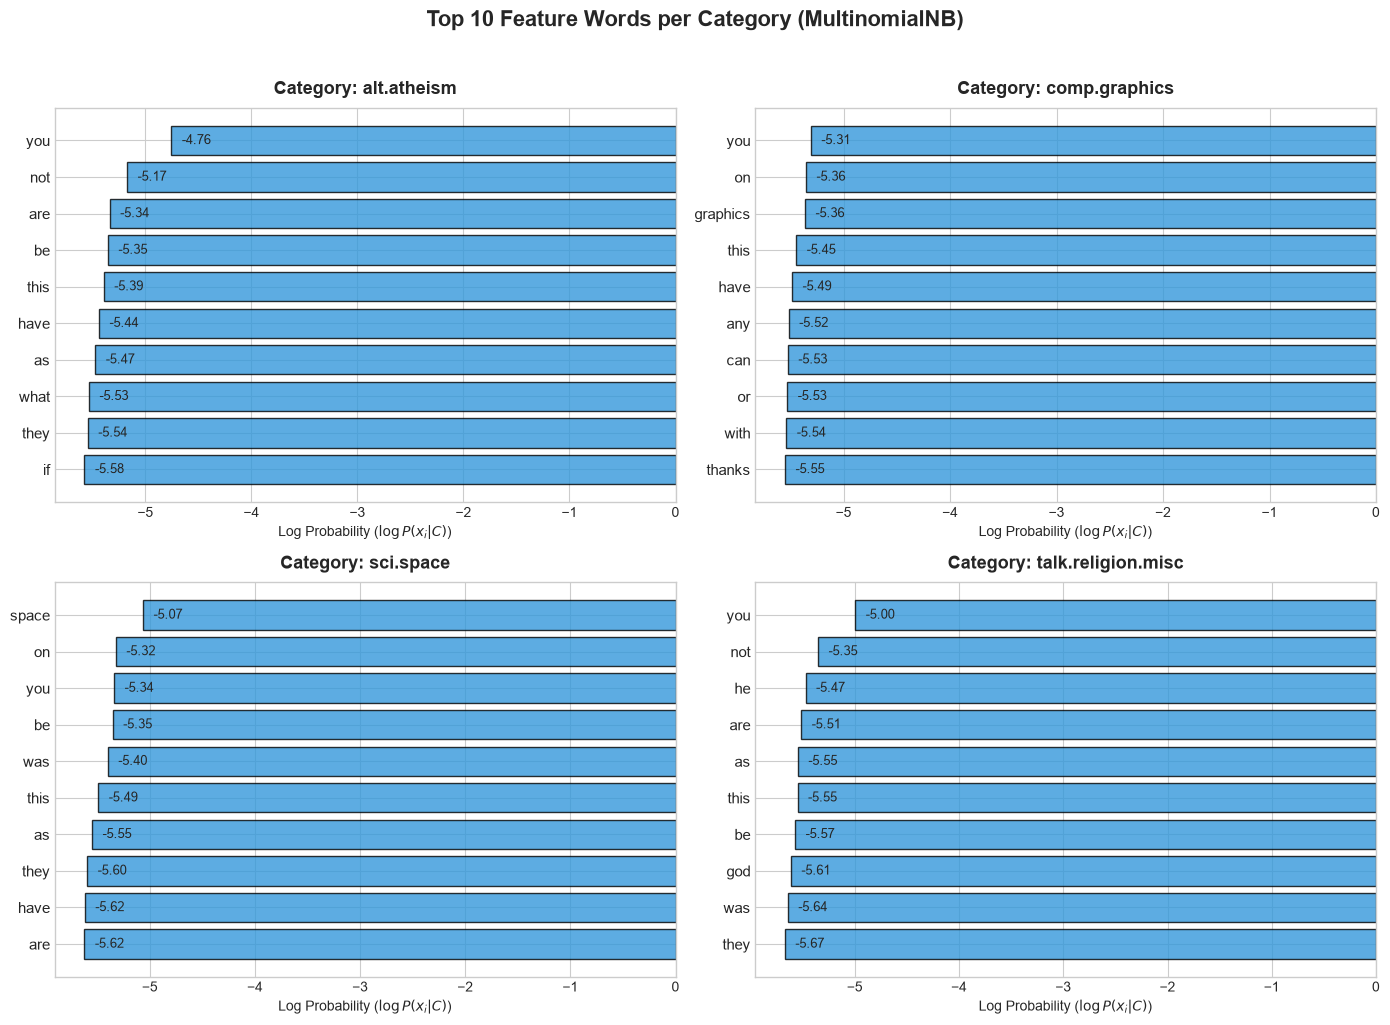

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. 시각화 대상 4개 뉴스그룹 카테고리 데이터 로드
# remove 파라미터로 헤더, 푸터, 인용문 등의 RFC 노이즈 텍스트 정제
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']
newsgroups_train = fetch_20newsgroups(subset='train', 
                                     remove=('headers', 'footers', 'quotes'), 
                                     categories=categories)
X_train = newsgroups_train.data  # 학습용 원본 텍스트 리스트
y_train = newsgroups_train.target # 각 문서의 타겟 카테고리 라벨 (0~3)

# 2. TF-IDF 벡터라이저 객체 생성 및 텍스트 데이터 수치 변환
# max_features=2000: 상위 2,000개 단어 추출
# min_df=5: 5개 미만 문서 출현 단어 제외
# max_df=0.5: 50% 초과 문서 출현 불용어 제외
tfidf = TfidfVectorizer(max_features=2000, min_df=5, max_df=0.5)
X_train_tfidf = tfidf.fit_transform(X_train) # 단어장 학습 및 TF-IDF 희소 행렬 생성

# 3. TF-IDF가 구축한 2,000개 피처(단어) 목록을 NumPy 1차원 배열로 반환
feature_names = np.asarray(tfidf.get_feature_names_out())

# 4. 다항 나이브 베이즈(MultinomialNB) 분류기 객체 생성 및 학습
# TF-IDF 행렬과 정답 라벨을 바탕으로 클래스별 단어 가능도(Likelihood) 산출
NB_clf = MultinomialNB()
NB_clf.fit(X_train_tfidf, y_train)

# 5. Matplotlib 시각화 스타일 설정 및 2x2 서브플롯(Subplot) 레이아웃 생성
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else None
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # 2x2 2차원 배열 구조를 1차원 배열(0~3)로 펼침

target_categories = newsgroups_train.target_names # 카테고리 텍스트 이름 리스트

# 6. 4개 카테고리별 상위 10개 핵심 키워드 추출 및 시각화 반복문
for i, category in enumerate(target_categories):
    # i번째 카테고리에 해당하는 모든 피처 단어들의 로그 가능도 P(x_i | C) 추출
    log_prob = NB_clf.feature_log_prob_[i]
    
    # -log_prob 기준 정렬 시 내림차순(가장 높은 확률값 순)으로 정렬된 단어의 인덱스 상위 10개 반환
    top10_idx = np.argsort(-log_prob)[:10]
    
    # 가로 막대그래프(barh) 특성상 맨 위가 1위 단어가 되도록 [::-1] 슬라이싱으로 배열 역순 정렬
    top10_words = feature_names[top10_idx][::-1]
    top10_values = log_prob[top10_idx][::-1]
    
    # 가로 막대그래프 그리기
    bars = axes[i].barh(top10_words, top10_values, color='#3498db', edgecolor='black', alpha=0.8)
    
    # 서브플롯 제목, 축 라벨, 글꼴 설정
    axes[i].set_title(f"Category: {category}", fontsize=13, fontweight='bold', pad=10)
    axes[i].set_xlabel("Log Probability ($\log P(x_i | C)$)", fontsize=10)
    axes[i].tick_params(axis='y', labelsize=11)
    
    # 각 막대 우측에 로그 가능도 수치 텍스트 표시
    for bar in bars:
        width = bar.get_width()
        axes[i].text(width + 0.1, bar.get_y() + bar.get_height()/2, 
                     f'{width:.2f}', va='center', ha='left', fontsize=9)

# 7. 전체 차트 중앙 메인 타이틀 지정 및 레이아웃 정돈 후 출력
plt.suptitle("Top 10 Feature Words per Category (MultinomialNB)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [19]:
# scikit-learn의 linear_model 모듈에서 로지스틱 회귀(Logistic Regression) 분류기 클래스를 불러옵니다.
from sklearn.linear_model import LogisticRegression #sklearn이 제공하는 logistic regression을 사용

# LogisticRegression 객체(분류기) 생성 및 선언
# 기본적으로 L2 규제(Ridge)와 C=1.0이 적용되어 모델의 과대적합(Overfitting)을 방지합니다.
LR_clf = LogisticRegression() #분류기 선언

# fit() 메서드를 사용하여 TF-IDF 변환된 학습 데이터셋(X_train_tfidf, y_train)으로 로지스틱 회귀 모델 학습
# 각 단어 피처가 카테고리 분류에 미치는 가중치(Coefficient, 회귀계수)를 경사하강법/최적화 알고리즘으로 학습합니다.
# ※ 참고: 상단 주석에는 'count vector'로 되어 있으나, 인자값으로는 TF-IDF 행렬인 'X_train_tfidf'가 입력되어 학습되고 있습니다.
LR_clf.fit(X_train_tfidf, y_train) # train data를 이용하여 분류기를 학습

# score() 메서드를 통해 학습 데이터셋(X_train_tfidf)에 대한 로지스틱 회귀 모델의 예측 정확도(Accuracy) 산출
print('Train set score: {:.3f}'.format(LR_clf.score(X_train_tfidf, y_train))) # train data에 대한 예측정확도

# score() 메서드를 통해 한 번도 보지 못한 검증 데이터셋(X_test_tfidf)에 대한 로지스틱 회귀 모델의 일반화 예측 정확도 산출
print('Test set score: {:.3f}'.format(LR_clf.score(X_test_tfidf, y_test))) # test data에 대한 예측정확도

Train set score: 0.930
Test set score: 0.740


In [20]:
import numpy as np

def calculate_ridge_loss(y_true, y_pred, weights, alpha):
    """
    릿지 회귀(Ridge Regression) 손실 함수 계산
    
    Parameters:
    - y_true: 실제값 (1D array)
    - y_pred: 예측값 (1D array)
    - weights: 모델의 가중치 패러미터 (1D array)
    - alpha: L2 규제 하이퍼파라미터 (float)
    """
    # 1. MSE (Mean Squared Error) 계산
    mse = np.mean((y_true - y_pred) ** 2)
    
    # 2. L2 규제항 (alpha * sum(w_j^2)) 계산
    l2_penalty = alpha * np.sum(weights ** 2)
    
    # 3. Ridge Loss = MSE + L2 Penalty
    ridge_loss = mse + l2_penalty
    
    return ridge_loss, mse, l2_penalty

# --- 테스트 예시 ---
if __name__ == "__main__":
    # 데이터 정의 (가상의 값)
    y_true = np.array([3.0, -0.5, 2.0, 7.0])
    y_pred = np.array([2.5, 0.0, 2.1, 7.8])
    weights = np.array([0.4, 1.2, -0.8, 0.5]) # p개의 가중치
    alpha = 0.1                                # 규제 강도

    loss, mse, penalty = calculate_ridge_loss(y_true, y_pred, weights, alpha)

    print(f"MSE (평균 제곱 오차) : {mse:.4f}")
    print(f"L2 Penalty (규제항)  : {penalty:.4f}")
    print(f"최종 Ridge Loss       : {loss:.4f}")

MSE (평균 제곱 오차) : 0.2875
L2 Penalty (규제항)  : 0.2490
최종 Ridge Loss       : 0.5365


In [28]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def top10_features(classifier, vectorizer, categories):
    """
    분류기 모델, 벡터화 객체, 카테고리 이름을 받아 
    각 카테고리별 상위 10개 피처(단어)를 출력하는 함수
    """
    # 벡터라이저에서 단어장 1D 배열 추출
    feature_names = np.asarray(vectorizer.get_feature_names_out())
    
    # 모델 종류에 맞춰 가중치/확률 배열 가져오기
    # - LogisticRegression: coef_ 사용
    # - Naive Bayes: feature_log_prob_ 사용
    if hasattr(classifier, 'coef_'):
        weights = classifier.coef_
    elif hasattr(classifier, 'feature_log_prob_'):
        weights = classifier.feature_log_prob_
    else:
        raise AttributeError("지원하지 않는 분류기 모델 형태입니다.")

    # 이진 분류(Binary Classification)인 경우 coef_ 배열 형태 맞춤 (1D -> 2D)
    if weights.shape[0] == 1 and len(categories) == 2:
        # 이진 분류 시 0번 카테고리는 -coef_, 1번 카테고리는 +coef_
        weights = np.vstack([-weights[0], weights[0]])

    # 카테고리별 상위 10개 단어 추출
    for i, category in enumerate(categories):
        # 내림차순 정렬을 위해 마이너스(-) 부호를 붙여 argsort 진행
        top10_idx = np.argsort(-weights[i])[:10]
        top10_words = feature_names[top10_idx]
        
        print(f"{category}: {', '.join(top10_words)}")

In [29]:
# scikit-learn의 linear_model 모듈에서 릿지 분류기(Ridge Classifier) 클래스를 불러옵니다.
from sklearn.linear_model import RidgeClassifier  #sklearn이 제공하는 ridge classifier를 사용

# RidgeClassifier 객체(분류기) 생성 및 선언
# 내부적으로 타겟 라벨을 {-1, 1} 형태의 변환값으로 바꾸어 릿지 회귀(Ridge Regression) 알고리즘을 적용한 후,
# 가장 높은 예측값을 출력하는 클래스로 분류를 수행합니다. (기본 규제 강도 alpha=1.0 적용)
ridge_clf = RidgeClassifier() #릿지 분류기 선언

# fit() 메서드를 사용하여 TF-IDF 학습 데이터셋(X_train_tfidf)과 정답 라벨(y_train)로 릿지 분류기 모델 학습
# 각 단어 피처에 대한 L2 패널티 가중치(회귀계수)를 정규방정식 해법(Normal Equation)을 통해 산출합니다.
ridge_clf.fit(X_train_tfidf, y_train) #학습

# score() 메서드를 사용하여 학습 데이터셋(X_train_tfidf)에 대한 릿지 분류기의 예측 정확도(Accuracy) 산출
print('Train set score: {:.3f}'.format(ridge_clf.score(X_train_tfidf, y_train)))

# score() 메서드를 사용하여 한 번도 보지 못한 평가 데이터셋(X_test_tfidf)에 대한 릿지 분류기의 검증 예측 정확도 산출
print('Test set score: {:.3f}'.format(ridge_clf.score(X_test_tfidf, y_test)))

Train set score: 0.960
Test set score: 0.735


In [30]:
# 배열 연산 및 일정 간격 수치 생성을 위한 NumPy와 데이터 분일을 위한 train_test_split 불러오기
import numpy as np
from sklearn.model_selection import train_test_split

# [데이터 분할] 기존 학습 데이터셋(X_train_tfidf, y_train)을 다시 '최종 학습용(80%)'과 '하리파라미터 검증용(20%)'으로 분할
# test_size=0.2: 20%를 검증 세트(Validation Set)로 사용
# random_state=42: 재현성(Reproducibility)을 위한 난수 고정
X_train_ridge, X_val_ridge, y_train_ridge, y_val_ridge = train_test_split(
    X_train_tfidf, y_train, test_size=0.2, random_state=42)

# 최적의 검증 정확도(max_score)와 그때의 alpha 하이퍼파라미터 값(max_alpha)을 저장할 변수 초기화
max_score = 0
max_alpha = 0

# np.arange(0.1, 10, 0.1): alpha 규제 값을 0.1부터 시작하여 0.1씩 증가시키며 10 미만까지 반복 수행
for alpha in np.arange(0.1, 10, 0.1): # alpha를 0.1부터 10까지 0.1씩 증가
    # 설정한 alpha 값을 반영하여 릿지 분류기(RidgeClassifier) 객체 생성
    # alpha가 클수록 규제(L2 Penalty)가 강해져 오버피팅을 방지하고, 작을수록 모델 학습 정밀도가 높아집니다.
    ridge_clf = RidgeClassifier(alpha=alpha) #릿지 분류기 선언
    
    # 분할된 '최종 학습용 데이터셋(X_train_ridge, y_train_ridge)'으로 모델 학습
    ridge_clf.fit(X_train_ridge, y_train_ridge) #학습
    
    # '검증 데이터셋(X_val_ridge, y_val_ridge)'을 넣어 현재 alpha 값에서의 예측 정확도 산출
    score = ridge_clf.score(X_val_ridge, y_val_ridge) #검정 데이터셋에 대해 정확도를 측정
    
    # 현재 검증 정확도가 기존 기록된 최고 정확도(max_score)보다 높은 경우 갱신
    if score > max_score: #정확도가 이전의 정확도 최대값보다 크면 최대값을 변경한다.
        max_score = score
        max_alpha = alpha

# 탐색을 통해 찾아낸 최적의 alpha 값과 그때의 최고 검증 정확도(Validation Score) 출력
print('Max alpha {:.3f} at max validation score {:.3f}'.format(max_alpha, max_score))

Max alpha 1.200 at max validation score 0.823


In [32]:
# LogisticRegression 클래스에 penalty='l1' 속성을 지정하여 라쏘(Lasso) 규제가 적용된 분류기 객체 생성
# - penalty='l1': 가중치의 절댓값 합에 비례하는 L1 규제를 적용하여 불필요한 단어의 계수를 완전히 0으로 만듦
# - solver='liblinear': L1 규제 손실 함수를 지원하는 최적화 솔버 지정 (작거나 중간 규모 데이터셋 및 L1 규제에 적합)
# - C=1: 규제 강도의 역수 (C 값이 작을수록 L1 규제가 강력해져 계수가 0이 되는 단어가 늘어남)
lasso_clf = LogisticRegression(l1_ratio=1.0, solver='saga', C=1, max_iter=10000) # Lasso는 동일한 LogisticRegression을 사용하면서 매개변수로 지정

# TF-IDF 변환된 학습 데이터셋(X_train_tfidf)과 정답 라벨(y_train)로 라쏘 로지스틱 회귀 모델 학습
lasso_clf.fit(X_train_tfidf, y_train) # train data로 학습

# 학습 데이터셋(X_train_tfidf)에 대한 라쏘 모델의 예측 정확도(Accuracy) 출력
print('#Train set score: {:.3f}'.format(lasso_clf.score(X_train_tfidf, y_train)))

# 검증/평가 데이터셋(X_test_tfidf)에 대한 라쏘 모델의 예측 정확도(Accuracy) 출력
print('#Test set score: {:.3f}'.format(lasso_clf.score(X_test_tfidf, y_test)))

# 계수(coefficient) 중에서 0이 아닌 것들의 개수를 출력
# lasso_clf.coef_ != 0: 각 카테고리별 회귀계수(coef_) 원소 중 0이 아닌 피처에 True(1), 0인 피처에 False(0)를 반환하는 불리언 배열 생성
# np.sum(...): True의 총개수를 합산하여 실제로 분류 예측에 사용된(선택된) 피처의 총 수 산출
# X_train_tfidf.shape[1]: 전체 단어장 피처의 총 수 (예: 2000개)
print('#Used features count: {}'.format(np.sum(lasso_clf.coef_ != 0)), 'out of', X_train_tfidf.shape[1])

top10_features(lasso_clf, tfidf, newsgroups_train.target_names)

#Train set score: 0.814
#Test set score: 0.705
#Used features count: 300 out of 2000
alt.atheism: bobby, tek, atheism, atheists, islam, islamic, religion, motto, atheist, punishment
comp.graphics: graphics, image, file, 3d, computer, hi, video, files, ftp, points
sci.space: space, orbit, nasa, launch, flight, spacecraft, moon, dc, shuttle, cost
talk.religion.misc: christians, christian, fbi, order, christ, children, jesus, god, his, blood


In [41]:
# NLTK 도구 및 관련 모듈 불러오기
from nltk.corpus import stopwords
cachedStopWords = stopwords.words("english") # (미사용 변수) 불용어 리스트 캐싱

from nltk.tokenize import RegexpTokenizer
from nltk.stem.porter import PorterStemmer
import re

# 단어 길이가 3글자 이상인 알파벳/숫자/아포스트로피 문자열만 추출하는 정규표현식 토크나이저 정의
RegTok = RegexpTokenizer(r"[\w']{3,}") # 정규표현식으로 토크나이저를 정의
english_stops = set(stopwords.words('english')) # NLTK의 영어 불용어(Stopwords) 집합 생성 (set 자료형으로 빠른 탐색)

porter_stemmer = PorterStemmer()


# 사용자 정의 전처리 토크나이저 함수
def tokenizer(text):
    # 1. 소문자 변환(text.lower()) 후 정규표현식을 적용하여 토큰 추출
    tokens = RegTok.tokenize(text.lower()) # [검토 결과] 정밀하게 잘 동작하는 올바른 방식입니다.

    # 2. 불용어(stopwords)에 해당하지 않고, 글자 길이가 2글자 초과(3글자 이상)인 단어만 필터링
    words = [word for word in tokens if (word not in english_stops) and len(word) > 2]

    # 3. PorterStemmer를 사용하여 단어의 어간(Stemming) 추출 (예: 'running', 'runs' -> 'run')
    # ※ 주의: 루프 내부에서 PorterStemmer() 객체를 매번 생성하는 것보다 함수 외부에서 1번만 생성하는 것이 연산 속도상 유리합니다.
    features = (list(map(lambda token: PorterStemmer().stem(token), words)))

    return features

# 커스텀 tokenizer를 적용하여 TfidfVectorizer 객체 생성
# - max_features=2000: 상위 2,000개 어간 피처 추출
# - min_df=5, max_df=0.5: 문서 빈도 기반 노이즈 단어 제어
tfidf = TfidfVectorizer(tokenizer=tokenizer, token_pattern=None) # 새로 정의한 토크나이저 사용

# 학습 데이터셋(X_train)을 바탕으로 어간 사전 구축 및 TF-IDF 행렬 변환
X_train_tfidf = tfidf.fit_transform(X_train) # train set을 변환

# 평가 데이터셋(X_test)을 동일한 어간 기준 단어장에 맞추어 수치 행렬 변환 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test) # test set을 변환

# 커스텀 전처리된 TF-IDF 벡터 기반으로 로지스틱 회귀(Logistic Regression) 모델 생성 및 학습
LR_clf = LogisticRegression() #분류기 선언
LR_clf.fit(X_train_tfidf, y_train) # train data를 이용하여 분류기를 학습

# 학습 데이터 및 평가 데이터 예측 정확도 출력
print('#Train set score: {:.3f}'.format(LR_clf.score(X_train_tfidf, y_train))) # train data에 대한 예측정확도
print('#Test set score: {:.3f}'.format(LR_clf.score(X_test_tfidf, y_test))) # test data에 대한 예측정확도

#Train set score: 0.962
#Test set score: 0.763


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 샘플 문서: 문맥에 따라 어조가 반대인 두 문장
corpus = [
    "This news is not good, very bad",
    "This news is good, not very bad"
]

# 1. Unigram만 사용 (기존 카운트 방식)
tfidf_unigram = TfidfVectorizer(ngram_range=(1, 1))
X_uni = tfidf_unigram.fit_transform(corpus)
print("[Unigram 피처 목록]:", tfidf_unigram.get_feature_names_out())
# 결과: 'bad', 'good', 'is', 'news', 'not', 'this', 'very' (단어 순서 무시됨)

# 2. Unigram + Bigram 동시 활용 (N-gram 적용 보완)
# ngram_range=(1, 2) -> 단어 1개 단어장과 연속된 단어 2개 단어장을 모두 생성
tfidf_bigram = TfidfVectorizer(ngram_range=(1, 2))
X_bi = tfidf_bigram.fit_transform(corpus)
print("\n[Unigram + Bigram 피처 목록]:")
print(tfidf_bigram.get_feature_names_out())
# 결과: 'not good', 'very bad', 'not very' 등 문맥 피처가 새롭게 생성됨!

[Unigram 피처 목록]: ['bad' 'good' 'is' 'news' 'not' 'this' 'very']

[Unigram + Bigram 피처 목록]:
['bad' 'good' 'good not' 'good very' 'is' 'is good' 'is not' 'news'
 'news is' 'not' 'not good' 'not very' 'this' 'this news' 'very'
 'very bad']


In [45]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# 1. 20newsgroups 데이터셋 로드 (4개 카테고리)
categories = ['alt.atheism', 'talk.religion.misc', 'comp.graphics', 'sci.space']

news_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
news_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

X_train, y_train = news_train.data, news_train.target
X_test, y_test = news_test.data, news_test.target

# 2. 평가 및 비교 결과를 담을 파이프라인 함수 정의
def evaluate_ngram(ngram_range, max_features=None):
    # TfidfVectorizer 생성
    tfidf = TfidfVectorizer(
        ngram_range=ngram_range,
        max_features=max_features,
        min_df=5,
        max_df=0.5
    )

    # 텍스트 데이터 수치 변환
    X_tr = tfidf.fit_transform(X_train)
    X_te = tfidf.transform(X_test)

    # LogisticRegression 모델 학습 및 평가
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_train)

    train_score = clf.score(X_tr, y_train)
    test_score = clf.score(X_te, y_test)
    num_features = X_tr.shape[1]

    return num_features, train_score, test_score

# 3. 실험 1: Unigram만 사용 (ngram_range=(1, 1))
features_1, train_acc_1, test_acc_1 = evaluate_ngram(ngram_range=(1, 1), max_features=2000)

# 4. 실험 2: Unigram + Bigram 사용 (ngram_range=(1, 2), 상위 2000개 고정)
features_2, train_acc_2, test_acc_2 = evaluate_ngram(ngram_range=(1, 2), max_features=2000)

# 5. 실험 3: Unigram + Bigram 사용 (ngram_range=(1, 2), max_features 제약 해제)
features_3, train_acc_3, test_acc_3 = evaluate_ngram(ngram_range=(1, 2), max_features=None)

# 6. 결과를 Pandas DataFrame 표 형태로 정리 및 비교 출력
results = pd.DataFrame({
    'N-gram Range': ['Unigram (1, 1)', 'Unigram+Bigram (1, 2)', 'Unigram+Bigram (1, 2)'],
    'max_features': [2000, 2000, 'Unlimited'],
    'Feature Count': [features_1, features_2, features_3],
    'Train Score': [f"{train_acc_1:.3f}", f"{train_acc_2:.3f}", f"{train_acc_3:.3f}"],
    'Test Score': [f"{test_acc_1:.3f}", f"{test_acc_2:.3f}", f"{test_acc_3:.3f}"]
})

print("=== N-gram 범위에 따른 Logistic Regression 성능 비교 ===")
print(results.to_string(index=False))

=== N-gram 범위에 따른 Logistic Regression 성능 비교 ===
         N-gram Range max_features  Feature Count Train Score Test Score
       Unigram (1, 1)         2000           2000       0.930      0.740
Unigram+Bigram (1, 2)         2000           2000       0.922      0.728
Unigram+Bigram (1, 2)    Unlimited          13482       0.965      0.749


In [46]:
# scikit-learn의 선형 모델 모듈에서 릿지 분류기(RidgeClassifier) 클래스 불러오기
from sklearn.linear_model import RidgeClassifier

# RidgeClassifier 객체(분류기) 생성 및 선언
# - 내부적으로 클래스 라벨을 {-1, 1} 형태의 변환값으로 바꾸어 릿지 회귀(Ridge Regression) 알고리즘을 적용한 후,
#   가장 높은 예측 수치를 출력하는 클래스로 분류를 수행합니다. (기본 L2 규제 강도 alpha=1.0 적용)
ridge_clf = RidgeClassifier() #릿지 분류기 선언

# fit() 메서드를 사용하여 TF-IDF 학습 데이터셋(X_train_tfidf)과 정답 라벨(y_train)로 릿지 분류기 모델 학습
# 각 단어 피처에 대한 L2 패널티 가중치(회귀계수)를 정규방정식 해법(Normal Equation)을 통해 한 번에 산출합니다.
ridge_clf.fit(X_train_tfidf, y_train) #학습

# score() 메서드를 사용하여 학습 데이터셋(X_train_tfidf)에 대한 릿지 분류기의 예측 정확도(Accuracy) 산출
print('Train set score: {:.3f}'.format(ridge_clf.score(X_train_tfidf, y_train)))

# score() 메서드를 사용하여 평가 데이터셋(X_test_tfidf)에 대한 릿지 분류기의 일반화 예측 정확도 산출
print('Test set score: {:.3f}'.format(ridge_clf.score(X_test_tfidf, y_test)))

Train set score: 0.976
Test set score: 0.763


In [47]:
# TfidfVectorizer 객체 생성 및 주요 파라미터 설정
tfidf = TfidfVectorizer(
    # 정규표현식 토큰 패턴: 영문 대소문자 및 아포스트로피(')로 구성된 3글자 이상의 단어만 추출 (숫자/특수문자 제외)
    token_pattern="[a-zA-Z']{3,}",

    # 디코딩 에러 처리: UTF-8 등 텍스트 읽기 중 발생하는 바이너리/인코딩 오류 문자를 무시하고 계속 진행
    decode_error='ignore',

    # 소문자화: 모든 텍스트를 소문자로 일괄 변환하여 대소문자 간 피처 중복 방지
    lowercase=True,

    # 불용어 제거: NLTK의 영어 불용어(Stopwords) 리스트를 적용하여 의미 없는 고빈도 단어 제외
    stop_words=stopwords.words('english'),

    # N-gram 범위: Unigram(1단어)과 Bigram(연속된 2단어 조합)을 함께 추출하여 어순 및 문맥 정보 반영
    ngram_range=(1, 2), # 바이그램 설정

    # 최대 문서 빈도 제한: 전체 문서의 50% 초과로 등장하는 지나치게 흔한 단어 제외
    max_df=0.5,

    # 최소 문서 빈도 제한: 전체 문서 중 최소 2개 이상의 문서에서 등장한 단어만 피처로 채택 (희귀 노이즈 단어 제거)
    min_df=2
)

# 학습 데이터셋(X_train)을 바탕으로 단어장(Vocabulary)을 구축하고 희소 행렬(Sparse Matrix)로 변환
X_train_tfidf = tfidf.fit_transform(X_train)

# 학습된 단어장 및 IDF 기준을 그대로 적용하여 평가 데이터셋(X_test)을 희소 행렬로 변환 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test)

# 변환된 학습 데이터 행렬의 차원(Shape) 출력
# 출력 형태: (문서 개수, 추출된 총 N-gram 피처 개수)
print(X_train_tfidf.shape)

(2034, 26410)


In [50]:
tfidf = TfidfVectorizer(token_pattern= "[a-zA-Z']{3,}", 
                        decode_error ='ignore', 
                        lowercase=True, 
                        stop_words = stopwords.words('english'),
                        ngram_range=(1, 2), # 바이그램 설정
                        max_df=0.5,
                        min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)

bigram_features = [f for f in tfidf.get_feature_names_out() if len(f.split()) > 1]
print('bi-gram samples:', bigram_features[:10])

ridge_clf.fit(X_train_tfidf, y_train) #학습
print('Train set score: {:.3f}'.format(ridge_clf.score(X_train_tfidf, y_train)))
print('Test set score: {:.3f}'.format(ridge_clf.score(X_test_tfidf, y_test)))

print(X_train_tfidf.shape)

(2034, 26410)
bi-gram samples: ["'cause can't", "'em better", "'expected errors'", "'karla' next", "'nodis' password", "'official doctrine", "'ok see", "'sci astro'", "'what's moonbase", 'aas american']
Train set score: 0.976
Test set score: 0.774
(2034, 26410)


In [51]:
# 판다스(Pandas) 라이브러리를 불러와 pd라는 약칭으로 사용합니다.
import pandas as pd

# pd.read_csv() 함수를 이용하여 지정한 경로('./data/daum_movie_review.csv')의 CSV 파일을 읽어와 데이터프레임(DataFrame) 객체 'df'에 저장합니다.
# 상대 경로 './'는 현재 파이프라인/노트북 파일이 위치한 작업 디렉토리를 의미합니다.
df = pd.read_csv('./data/daum_movie_review.csv')

# .head(5) 메서드를 사용하여 로드된 데이터프레임의 상단 5개 행(Row) 데이터를 미리보기 형태로 출력합니다.
# 데이터의 주요 컬럼 구성(예: review_text, rating, movie_title 등)과 결측치 유무를 파악하기 좋습니다.
df.head(5)

,review,rating,date,title
0,돈 들인건 티가 나지만 보는 내내 하품만,1,2018.10.29,인피니티 워
1,몰입할수밖에 없다. 어렵게 생각할 필요없다. 내가 전투에 참여한듯 손에 땀이남.,10,2018.10.26,인피니티 워
2,이전 작품에 비해 더 화려하고 스케일도 커졌지만.... 전국 맛집의 음식들을 한데 ...,8,2018.10.24,인피니티 워
3,이 정도면 볼만하다고 할 수 있음!,8,2018.10.22,인피니티 워
4,재미있다,10,2018.10.20,인피니티 워


In [52]:
print(df.title.value_counts())

title
신과함께      4947
택시운전사     2322
인피니티 워    2042
범죄도시      1939
곤지암       1547
라라랜드      1150
코코         778
Name: count, dtype: int64


In [53]:
# scikit-learn의 model_selection 모듈에서 Train/Test 데이터 분할 함수 불러오기
from sklearn.model_selection import train_test_split

# train_test_split() 함수를 사용하여 리뷰 텍스트(df.review)와 라벨(df.title)을 학습용/테스트용으로 분할
# - df.review: 독립변수 (X, 모델이 학습할 영화 리뷰 텍스트)
# - df.title: 종속변수 (y, 예측 대상인 영화 제목)
# - random_state=0: 난수 생성 고정값 지정 (매번 실행할 때마다 동일한 비율로 동일하게 데이터가 분할되도록 제어)
# - test_size 비율을 별도로 지정하지 않았으므로 기본값(Default)인 Train:Test = 75%:25% 비율로 자동 분할됨
X_train, X_test, y_train, y_test = train_test_split(df.review, df.title, random_state=0)

# len() 함수를 통해 분할된 학습 데이터셋(X_train)의 샘플(리뷰) 개수 출력
print('#Train set size:', len(X_train))

# len() 함수를 통해 분할된 테스트 데이터셋(X_test)의 샘플(리뷰) 개수 출력
print('#Test set size:', len(X_test))

#Train set size: 11043
#Test set size: 3682


In [54]:
# 한국어 자연어 처리(NLP) 파이썬 라이브러리인 KoNLPy에서 Okt(Open Korean Text) 형태소 분석기 클래스 불러오기
from konlpy.tag import Okt #konlpy에서 Twitter 형태소 분석기를 import

# 과거 버전 주석: Okt는 이전 버전 KoNLPy에서 'Twitter'라는 이름으로 제공되었으나, 정식 버전업을 거치며 'Okt'로 명칭이 변경되었습니다.
#from konlpy.tag import Twitter #konlpy에서 Twitter 형태소 분석기를 import

# Okt 형태소 분석기 객체 생성
okt = Okt()

# .morphs() 메서드: 입력 텍스트를 최소 의미 단위인 '형태소(Morph)' 단위로 분할하여 리스트로 반환
# X_train[1]: 학습용 데이터셋의 2번째 리뷰 문장에 대해 형태소 분할 수행
print(okt.morphs(X_train[1])) #둘째 리뷰에 대해 형태소 단위로 tokenize

# .nouns() 메서드: 입력 텍스트 내에서 '명사(Noun)'에 해당하는 형태소들만 필터링하여 리스트로 반환
# 텍스트 분류 시 조사/어미를 제외하고 의미 있는 핵심 키워드(명사)만 피처로 사용하고 싶을 때 주로 활용
print(okt.nouns(X_train[1])) #둘째 리뷰에서 명사만 추출

['몰입', '할수밖에', '없다', '.', '어렵게', '생각', '할', '필요없다', '.', '내', '가', '전투', '에', '참여', '한', '듯', '손', '에', '땀', '이남', '.']
['몰입', '생각', '내', '전투', '참여', '듯', '손', '땀', '이남']


In [55]:
# scikit-learn에서 TF-IDF 벡터라이저와 로지스틱 회귀 모델 불러오기
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# TfidfVectorizer 객체 생성
# - tokenizer=okt.nouns: 앞에서 선언한 Okt 객체의 명사 추출 메서드(.nouns)를 커스텀 토크나이저로 직접 전달하여 텍스트에서 '명사'만 토큰으로 추출
# - max_features=2000: TF-IDF 가중치 상위 2,000개의 명사 피처만 채택하여 단어장 차원 제한
# - min_df=5: 전체 리뷰 중 최소 5개 이상의 문서에서 등장한 명사만 피처로 사용 (희귀 오탈자/노이즈 제거)
# - max_df=0.5: 전체 리뷰의 50% 초과로 흔하게 등장하는 명사 제외 (범용적인 단어 제거)
tfidf = TfidfVectorizer(tokenizer=okt.nouns, max_features=2000, min_df=5, max_df=0.5) 

# 학습 데이터셋(X_train 리뷰 텍스트)을 바탕으로 명사 단어장 구축 및 TF-IDF 희소 행렬로 변환
X_train_tfidf = tfidf.fit_transform(X_train) # train data 변환 -> tfidf vector

# 구축된 명사 단어장 및 IDF 수치를 기준으로 평가 데이터셋(X_test)을 수치 행렬로 변환 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test) # test data 변환 -> tfidf vector

# 로지스틱 회귀(Logistic Regression) 분류기 객체 생성 및 선언
# - max_iter=1000: 경사하강법 최적화 반복 횟수를 1,000회로 지정 (기본값 100회 사용 시 수렴 미달 경고가 뜨는 현상 방지)
clf = LogisticRegression(max_iter=1000) # 충분한 학습을 위해 max_iter를 1,000으로 설정, 기본은 100

# 명사 TF-IDF 벡터화된 학습 데이터셋(X_train_tfidf)과 영화 제목 라벨(y_train)로 로지스틱 회귀 모델 학습
clf.fit(X_train_tfidf, y_train) # 분류기 학습

# 학습 데이터셋에 대한 예측 정확도(Accuracy) 출력
print('#Train set score: {:.3f}'.format(clf.score(X_train_tfidf, y_train))) # train data 예측정확도

# 평가 데이터셋에 대한 검증 예측 정확도(Accuracy) 출력
print('#Test set score: {:.3f}'.format(clf.score(X_test_tfidf, y_test))) # test data 예측정확도

c:\sk-encoa\dl_workspace\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


#Train set score: 0.756
#Test set score: 0.694


In [56]:
# 출력 결과물의 각 항목(열)을 구분하기 위한 헤더 제목 문구 출력
print('실제영화제목, 예측한 제목, 리뷰')

# zip() 함수를 사용하여 3가지 요소의 상위 10개 항목을 1:1 튜플(Tuple) 형태로 묶어 루프 수행
# - y_test[:10]: 테스트 세트의 실제 정답 영화 제목 상위 10개
# - clf.predict(X_test_tfidf[:10]): 학습된 로지스틱 회귀 모델(clf)이 TF-IDF 벡터를 입력받아 예측한 영화 제목 상위 10개
# - X_test[:10]: 평가에 사용된 원본 영화 리뷰 텍스트 상위 10개
for content in zip(y_test[:10], clf.predict(X_test_tfidf[:10]), X_test[:10]):
    # (실제 영화 제목, 예측한 영화 제목, 원본 리뷰 텍스트) 형태의 튜플 출력
    print(content)

실제영화제목, 예측한 제목, 리뷰
('범죄도시', '신과함께', '오랜만에 잼나는 영화 봤습니다.  다음에 더 재미있는 영화 기대하겠습니다.')
('범죄도시', '범죄도시', '조연들이 눈에 박힌다. 간만에 집중 ㅎ')
('코코', '코코', '대감동을 선사. 인사이드 아웃을 잇는 픽사의 감동스토리. 신과함께의 멕시코판이라고나할까요??')
('신과함께', '신과함께', '돈이 안아까웠던 영화ᆞᆞ  정말 좋았다')
('신과함께', '신과함께', '역시 김용화감독이 영화는 잘 만들어요. 이제 VFX 제작 부문도 헐리우드 수준 이상입니다.')
('택시운전사', '택시운전사', '민주화를 위해 힘써주신 분들께 감사하는 마음으로 살아야겠다.')
('신과함께', '신과함께', '잠만 자다 왔음')
('신과함께', '신과함께', '오랜만에 잼있고 좋은 영화를 봤다')
('범죄도시', '신과함께', '잼남')
('범죄도시', '인피니티 워', '대박~~')


In [58]:
# TfidfVectorizer 객체 생성
# - tokenizer=okt.morphs: 명사뿐만 아니라 조사, 어미, 형용사, 동사 등 문장을 구성하는 모든 형태소 단위로 토큰화 진행
# - max_features=2000: TF-IDF 가중치 상위 2,000개 형태소 피처만 선택하여 차원 제한
# - min_df=5: 전체 리뷰 중 최소 5개 이상의 문서에서 등장한 형태소만 피처로 사용 (희귀 단어 및 노이즈 제거)
# - max_df=0.5: 전체 리뷰의 50% 초과로 흔하게 등장하는 형태소 제외 (조사 등 지나치게 범용적인 단어 제어)
tfidf = TfidfVectorizer(tokenizer=okt.morphs, token_pattern= None, max_features=2000, min_df=5, max_df=0.5) # 명사 대신 모든 형태소를 사용

# 학습 데이터셋(X_train 리뷰 텍스트)을 바탕으로 전체 형태소 단어장을 구축하고 TF-IDF 희소 행렬로 변환
X_train_tfidf = tfidf.fit_transform(X_train)

# 구축된 단어장과 IDF 수치를 기준으로 평가 데이터셋(X_test)을 수치 행렬로 변환 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test)

# 로지스틱 회귀(Logistic Regression) 분류기 객체 생성
# - max_iter=1000: 최적화 수렴을 위해 반복 횟수를 1,000회로 지정 (기본값 100회 시 수렴 미달 경고 방지)
clf = LogisticRegression(max_iter=1000) # 충분한 학습을 위해 max_iter를 1,000으로 설정, 기본은 100

# 형태소 TF-IDF 변환된 학습 데이터셋(X_train_tfidf)과 영화 제목 라벨(y_train)로 로지스틱 회귀 모델 학습
clf.fit(X_train_tfidf, y_train)

# 학습 데이터셋에 대한 예측 정확도(Accuracy) 출력
print('#Train set score: {:.3f}'.format(clf.score(X_train_tfidf, y_train))) # train data 예측정확도

# 평가 데이터셋에 대한 검증 예측 정확도(Accuracy) 출력
print('#Test set score: {:.3f}'.format(clf.score(X_test_tfidf, y_test))) # test data 예측정확도

#Train set score: 0.777
#Test set score: 0.694


In [61]:
# 커스텀 토크나이저 함수 정의: 문장에서 명사, 동사, 형용사만 선택적으로 추출
def twit_tokenizer(text): #전체를 다 사용하는 대신, 명사, 동사, 형용사를 사용
    # 추출 대상이 되는 품사 태그 리스트 지정 (조사, 구두점, 부사, 기호 등은 노이즈로 간주하여 제외)
    target_tags = ['Noun', 'Verb', 'Adjective']
    result = []

    # okt.pos(): 텍스트를 (단어, 품사태그) 튜플 형태 리스트로 반환
    # - norm=True: '작성헀넠ㅋㅋ' -> '작성했다' 처럼 신조어나 변형된 표현을 정규화
    # - stem=True: '재밌어요', '재밌었던' -> '재밌다' 처럼 원형(어간) 형태로 변환
    for word, tag in okt.pos(text, norm=True, stem=True):
        # 현재 형태소의 품사(tag)가 target_tags에 포함되는 경우에만 최종 토큰 리스트에 추가
        if tag in target_tags:
            result.append(word)

    return result

# TfidfVectorizer 객체 생성
# - tokenizer=twit_tokenizer: 위에서 정의한 [명사/동사/형용사 + 정규화 + 어간추출] 함수 적용
# - max_features=2000: 상위 2,000개 유효 키워드 피처 선택
# - min_df=5, max_df=0.5: 희귀 노이즈 단어 및 고빈도 범용 단어 제외
tfidf = TfidfVectorizer(tokenizer=twit_tokenizer, token_pattern=None, max_features=2000, min_df=5, max_df=0.5) #명사, 동사, 형용사를 이용하여 tfidf 생성

# 학습 데이터셋(X_train 리뷰 텍스트)을 정제된 키워드 단어장으로 구축하고 TF-IDF 희소 행렬로 변환
X_train_tfidf = tfidf.fit_transform(X_train)

# 학습된 단어장 기준으로 평가 데이터셋(X_test)을 수치 행렬로 변환 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test)

# 로지스틱 회귀(Logistic Regression) 모델 객체 생성
# - max_iter=1000: 경사하강법 최적화 수렴 횟수 지정
clf = LogisticRegression(max_iter=1000) # 충분한 학습을 위해 max_iter를 1,000으로 설정, 기본은 100

# 필터링된 TF-IDF 학습 데이터 세트로 로지스틱 회귀 모델 학습
clf.fit(X_train_tfidf, y_train)

# 학습 데이터셋 및 평가 데이터셋에 대한 예측 정확도(Accuracy) 출력
print('#Train set score: {:.3f}'.format(clf.score(X_train_tfidf, y_train))) # train data 예측정확도
print('#Test set score: {:.3f}'.format(clf.score(X_test_tfidf, y_test))) # test data 예측정확도

#Train set score: 0.783
#Test set score: 0.712


In [60]:
# 커스텀 토크나이저 함수 정의: 모든 형태소를 추출하되 단어 뒤에 품사 태그를 결합 (예: '영화/Noun')
def twit_tokenizer2(text): #모든 형태소를 다 사용하고 품사를 알 수 있도록 하면?
    result = []

    # okt.pos(): 입력 문장에 대해 (단어, 품사태그) 형태의 튜플 리스트 반환
    # - norm=True: 신조어나 비표준어 정규화 ('ㅋㅋ' -> 'ㅋㅋㅋ', '작성했넠' -> '작성했다')
    # - stem=True: 어간 추출을 적용하여 용언의 원형 변환 ('재밌어요' -> '재밌다')
    for word, tag in okt.pos(text, norm=True, stem=True):
        # '/'.join([word, tag])를 통해 '단어/품사' 형태의 하나의 문자열 토큰으로 결합하여 리스트에 추가
        result.append('/'.join([word, tag])) #단어의 품사를 구분할 수 있도록 함

    return result

# 함수 테스트: 학습용 데이터셋의 2번째 리뷰(X_train[1])에 대해 '단어/품사' 토큰 리스트 출력
print(twit_tokenizer2(X_train[1]))

['몰입/Noun', '하다/Verb', '없다/Adjective', './Punctuation', '어렵다/Adjective', '생각/Noun', '하다/Verb', '필요없다/Adjective', './Punctuation', '내/Noun', '가/Josa', '전투/Noun', '에/Josa', '참여/Noun', '한/Determiner', '듯/Noun', '손/Noun', '에/Josa', '땀/Noun', '이남/Noun', './Punctuation']


In [ ]:
# TfidfVectorizer 객체 생성
# - tokenizer=twit_tokenizer2: '단어/품사' (예: '영화/Noun', '재밌다/Adjective') 형태의 토큰을 생성하는 함수 적용
# - max_features=2000: 가중치 상위 2,000개 '단어/품사' 피처만 채택
# - min_df=5, max_df=0.5: 최소 5개 이상 문장에 등장하고 전체의 50%를 초과하지 않는 유효 형태소 태그만 추출
tfidf = TfidfVectorizer(tokenizer=twit_tokenizer2, token_pattern=None, max_features=2000, min_df=5, max_df=0.5)

# 학습 데이터셋(X_train 리뷰)을 '단어/품사' 피처 기반의 TF-IDF 희소 행렬로 변환
X_train_tfidf = tfidf.fit_transform(X_train)

# 학습된 단어장 기준으로 평가 데이터셋(X_test)을 동일한 규격의 희소 행렬로 변환 (Data Leakage 방지)
X_test_tfidf = tfidf.transform(X_test)

# 로지스틱 회귀(Logistic Regression) 분류기 객체 생성
# - max_iter=1000: 수렴 안정성을 위해 최대 반복 회수를 1,000회로 지정
clf = LogisticRegression(max_iter=1000) # 충분한 학습을 위해 max_iter를 1,000으로 설정, 기본은 100

# '단어/품사' TF-IDF 변환 데이터로 로지스틱 회귀 분류기 학습
clf.fit(X_train_tfidf, y_train)

# 학습 데이터셋 및 평가 데이터셋에 대한 예측 정확도(Accuracy) 출력
print('#Train set score: {:.3f}'.format(clf.score(X_train_tfidf, y_train))) # train data 예측정확도
print('#Test set score: {:.3f}'.format(clf.score(X_test_tfidf, y_test))) # test data 예측정확도

c:\sk-encoa\dl_workspace\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:527: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
